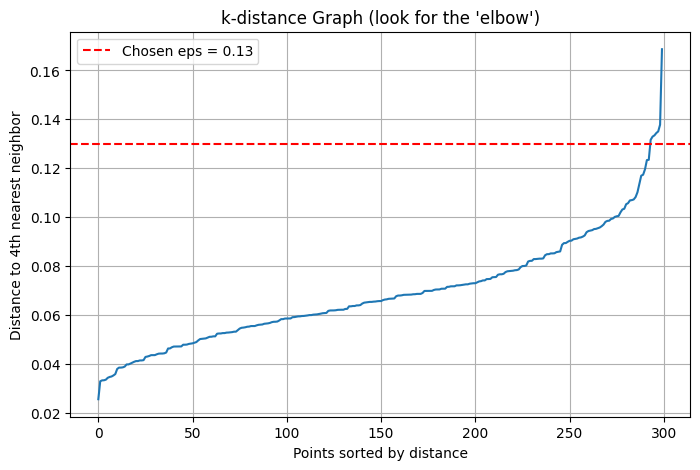

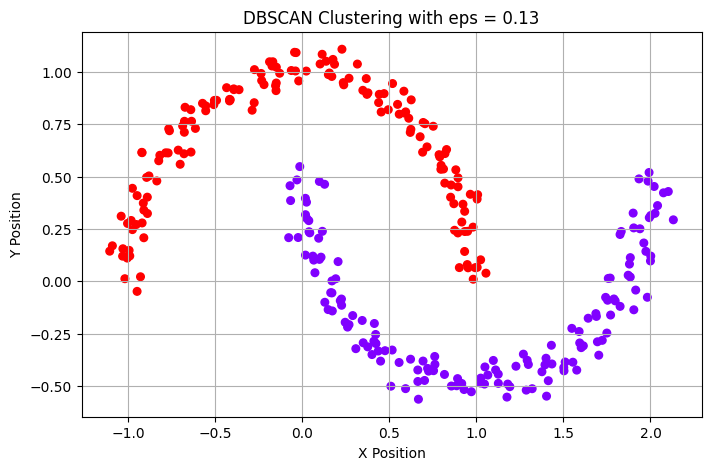

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
# for non-linear shapes

# Step 1: Generate data
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Step 2: k-distance plot to help choose eps
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:, 3])  # 4th nearest
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.axhline(y=0.13, color='r', linestyle='--', label='Chosen eps = 0.13')
plt.title("k-distance Graph (look for the 'elbow')")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 4th nearest neighbor")
plt.legend()
plt.grid(True)
plt.show()

# Step 3: Apply DBSCAN with chosen eps
dbscan = DBSCAN(eps=0.13, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 4: Plot clustering result
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', s=30)
plt.title("DBSCAN Clustering with eps = 0.13")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.grid(True)
plt.show()